In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


#from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score


from multiprocessing import Pool, cpu_count

import dask
import dask.dataframe as dd
from dask.distributed import Client
client = Client(n_workers=20, memory_limit="10GB", interface='lo')

import dask_ml.cluster as dask_cluster

from pprint import pprint
import os

/home/zwang937/anaconda3/lib/python3.7/site-packages/distributed/dashboard/core.py:72: UserWarning: 
Port 8787 is already in use. 
Perhaps you already have a cluster running?
Hosting the diagnostics dashboard on a random port instead.
  warnings.warn("\n" + msg)


### Import Individual GRF

In [2]:
# Individual GRFs by cutoff intermediate
def read_csv(file_path):
    return pd.read_csv(file_path)
def merge_dfs(dfs):
    return pd.concat(dfs, ignore_index=True)

intermediate_results_folder_path = "../data/output/intermediate_by_cutoff/"
csv_files = [os.path.join(intermediate_results_folder_path, f) for f in os.listdir(intermediate_results_folder_path) if f.endswith('.csv')]
pool = Pool()
dfs = pool.map(read_csv, csv_files)
merged_individual_grfs_df = merge_dfs(dfs)
merged_individual_grfs_df = merged_individual_grfs_df.sort_values(['days_from_start', 'fips'])
merged_individual_grfs_df.to_csv("../data/output/glob_merged_individual_grfs.csv",index=False)

Process ForkPoolWorker-37:
Process ForkPoolWorker-62:
Process ForkPoolWorker-106:
Process ForkPoolWorker-27:
Process ForkPoolWorker-100:
Process ForkPoolWorker-101:
Process ForkPoolWorker-96:
Process ForkPoolWorker-95:
Process ForkPoolWorker-74:
Process ForkPoolWorker-58:
Process ForkPoolWorker-56:
Process ForkPoolWorker-55:
Process ForkPoolWorker-87:
Process ForkPoolWorker-61:
Process ForkPoolWorker-36:
Process ForkPoolWorker-57:
Process ForkPoolWorker-92:
Process ForkPoolWorker-104:
Process ForkPoolWorker-54:
Process ForkPoolWorker-73:
Process ForkPoolWorker-89:
Process ForkPoolWorker-103:
Process ForkPoolWorker-40:
Process ForkPoolWorker-93:
Process ForkPoolWorker-82:
Process ForkPoolWorker-48:
Process ForkPoolWorker-67:
Process ForkPoolWorker-60:
Process ForkPoolWorker-98:
Process ForkPoolWorker-105:
Process ForkPoolWorker-30:
Process ForkPoolWorker-65:
Traceback (most recent call last):
Process ForkPoolWorker-21:
Process ForkPoolWorker-52:
Process ForkPoolWorker-43:
Process ForkPo

Traceback (most recent call last):
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
Traceback (most recent call last):
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
Traceback (most recent call last):
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
Traceback (most recent call last):
  File "/home/zwang937/anaconda3/lib/python3.7/multipro

  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/queues.py", line 351, in get
    with self._rlock:
Traceback (most recent call last):
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/pool.py", line 110, in worker
    task = get()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/process.py", line 99, in run
    self._target(*self._args, **self._kwargs)
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/process.py", line 99, in run
    self._target(*self._args, **self._kwargs)
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/process.py", line 99, in run
    self._target(*self._args, **self._kwargs)
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
  File "/home/zwang937/anac

Traceback (most recent call last):
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/process.py", line 99, in run
    self._target(*self._args, **self._kwargs)
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/queues.py", line 351, in get
    with self._rlock:
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/pool.py", line 110, in worker
    task = get()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/pool.py", line 110, in worker
    task = get()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/queues.py", line 351, in get
    with self._rlock:
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/pool.py", line 110, in worker
    task = get()
Process ForkPoolWorker-24:
  File "/hom

  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/process.py", line 99, in run
    self._target(*self._args, **self._kwargs)
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/process.py", line 99, in run
    self._target(*self._args, **self._kwargs)
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/pool.py", line 110, in worker
    task = get()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
KeyboardInterrupt
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
  File "/home/zwang937/anaconda3/lib/pyt

  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/pool.py", line 110, in worker
    task = get()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/pool.py", line 110, in worker
    task = get()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/pool.py", line 110, in worker
    task = get()
KeyboardInterrupt
KeyboardInterrupt
Traceback (most recent call last):
KeyboardInterrupt
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/queues.py", line 351, in get
    with self._rlock:
Traceback (most recent call last):
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/process.py", line 99, in run
    self._target(*self._args, **self._kwargs)
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/process.py", line 297, in _bootstrap
    self.run()
KeyboardInterrupt
  File "/home/zwang937

  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/pool.py", line 110, in worker
    task = get()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/queues.py", line 351, in get
    with self._rlock:
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
KeyboardInterrupt
Traceback (most recent call last):
KeyboardInterrupt
KeyboardInterrupt
KeyboardInterrupt
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/pool.py", line 110, in worker
    task = get()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
  F

  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/queues.py", line 351, in get
    with self._rlock:
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/queues.py", line 351, in get
    with self._rlock:
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/queues.py", line 351, in get
    with self._rlock:
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/connection.py", line 407, in _recv_bytes
    buf = self._recv(4)
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/pool.py", line 110, in worker
    task = get()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/pool.py", line 110, in worker
    task = get()
KeyboardInterrupt
  File "/home/zwang937/anaconda3/lib/python3.7/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
  File "/home/

In [3]:
(merged_individual_grfs_df).head()

,fips,county,state,days_from_start,datetime,log_rolled_cases.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days
1730019,6037,Los Angeles,California,53,2020-03-14,3.347395,780.705984,-0.005777,4.163408,3.083049,3.306957,-119.987116
1730015,6085,Santa Clara,California,53,2020-03-14,4.032976,NaN,-0.016267,NaN,3.741067,3.919108,-42.611200
1730017,25017,Middlesex,Massachusetts,53,2020-03-14,3.692445,NaN,0.011847,NaN,3.547032,3.775376,58.506201
1730018,36059,Nassau,New York,53,2020-03-14,3.534729,NaN,-0.021308,NaN,2.989569,3.385571,-32.529481
1730016,36119,Westchester,New York,53,2020-03-14,4.841935,NaN,-0.012171,NaN,4.613449,4.756738,-56.951041


### Import TLGRF RMSE and MAE

In [62]:
TLGRF_RMSE_path = "../data/output/block_mse_windowsize=2.csv" 
TLGRF_MAE_path = "../data/output/block_mae_windowsize=2.csv"

TLGRF_RMSE = pd.read_csv(TLGRF_RMSE_path)
TLGRF_RMSE["block.rmse.last"] = np.sqrt(TLGRF_RMSE["block.mse.last"])
TLGRF_RMSE = TLGRF_RMSE[["cutoff","block.rmse.last"]]
TLGRF_RMSE = TLGRF_RMSE.dropna(subset=["block.rmse.last"])

TLGRF_MAE = pd.read_csv(TLGRF_MAE_path)[["cutoff","block.mae.last"]]
TLGRF_performance = pd.merge(TLGRF_MAE,TLGRF_RMSE,on="cutoff",how="inner")


In [63]:
TLGRF_performance

,cutoff,block.mae.last,block.rmse.last
0,58,0.709696,0.781642
1,59,0.802498,0.846487
2,60,0.706543,0.791903
3,61,0.690295,0.791635
4,62,0.755220,0.828698
...,...,...,...
1012,1071,0.166673,0.260459
1013,1072,0.146886,0.224938
1014,1073,0.146455,0.230066
1015,1074,0.121997,0.177553


### Import Historical Data

In [4]:
cases_df_path = "../data/augmented_us-counties_latest.csv"
cases_df = dd.read_csv(cases_df_path, assume_missing=True)
cases_df = cases_df.compute()
cases_df = cases_df.sort_values(["fips","days_from_start"])
cases_df.head()

,fips,date,county,state,cases,deaths,datetime,days_from_start,rolled_cases,LAT,...,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP
767,1001.0,2020-03-30,Autauga,Alabama,7.0,0.0,2020-03-30,69.0,5.142857,32.532237,...,0.0,0.0,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0
827,1001.0,2020-03-31,Autauga,Alabama,7.0,0.0,2020-03-31,70.0,6.000000,32.532237,...,0.0,0.0,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0
243,1001.0,2020-04-01,Autauga,Alabama,10.0,0.0,2020-04-01,71.0,6.857143,32.532237,...,0.0,0.0,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0
141,1001.0,2020-04-02,Autauga,Alabama,10.0,0.0,2020-04-02,72.0,7.428571,32.532237,...,0.0,0.0,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0
969,1001.0,2020-04-03,Autauga,Alabama,12.0,0.0,2020-04-03,73.0,8.285714,32.532237,...,0.0,0.0,0.0,0.0,0.0,0.0,3875.0,7.1,0.9,37301.0


In [5]:
cases_df["log_rolled_cases"] = np.log(cases_df["rolled_cases"])
cases_df["shifted_log_rolled_cases"] = cases_df.groupby("fips")["log_rolled_cases"].shift(periods=-7)

/home/zwang937/anaconda3/lib/python3.7/site-packages/pandas/core/arraylike.py:364: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/zwang937/anaconda3/lib/python3.7/site-packages/pandas/core/arraylike.py:364: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [6]:
outcome_log_rolled_cases = cases_df[["days_from_start", "fips", "log_rolled_cases", "shifted_log_rolled_cases"]]
outcome_log_rolled_cases.head()

,days_from_start,fips,log_rolled_cases,shifted_log_rolled_cases
767,69.0,1001.0,1.637609,2.371578
827,70.0,1001.0,1.791759,2.436116
243,71.0,1001.0,1.925291,2.460809
141,72.0,1001.0,2.005334,2.542726
969,73.0,1001.0,2.114533,2.597385


In [38]:
individual_grfs_results_df = pd.merge(left=merged_individual_grfs_df, right=outcome_log_rolled_cases, on=["days_from_start","fips"], how="inner")
individual_grfs_results_df = individual_grfs_results_df.dropna(subset=["shifted_log_rolled_cases"])
individual_grfs_results_df = individual_grfs_results_df.loc[individual_grfs_results_df['shifted_log_rolled_cases'] != -np.inf]

individual_grfs_results_df.head()

,fips,county,state,days_from_start,datetime,log_rolled_cases.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,log_rolled_cases,shifted_log_rolled_cases
0,6037,Los Angeles,California,53,2020-03-14,3.347395,780.705984,-0.005777,4.163408,3.083049,3.306957,-119.987116,3.347395,5.272267
1,6085,Santa Clara,California,53,2020-03-14,4.032976,NaN,-0.016267,NaN,3.741067,3.919108,-42.611200,4.032976,5.156589
2,25017,Middlesex,Massachusetts,53,2020-03-14,3.692445,NaN,0.011847,NaN,3.547032,3.775376,58.506201,3.692445,4.722318
3,36059,Nassau,New York,53,2020-03-14,3.534729,NaN,-0.021308,NaN,2.989569,3.385571,-32.529481,3.534729,6.023448
4,36119,Westchester,New York,53,2020-03-14,4.841935,NaN,-0.012171,NaN,4.613449,4.756738,-56.951041,4.841935,6.488988


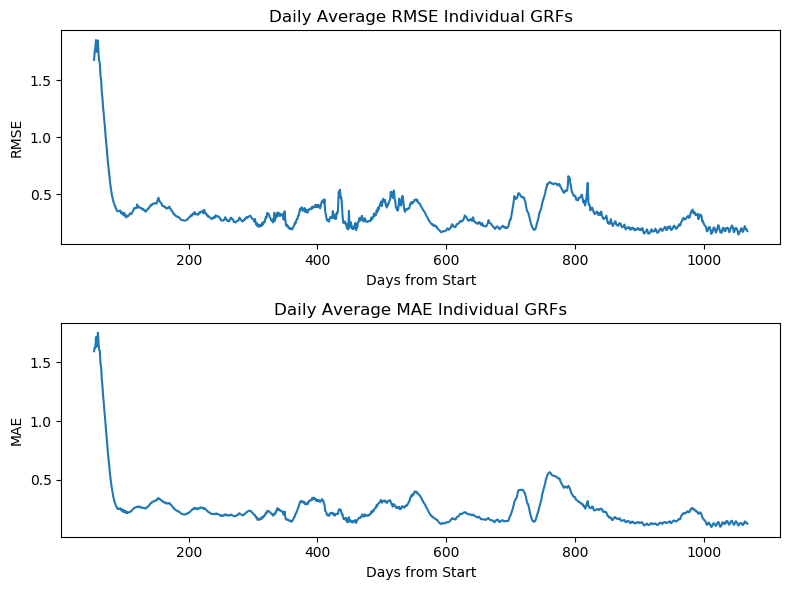

In [74]:
individual_grfs_rmse = individual_grfs_results_df.groupby('days_from_start').apply(lambda x: mean_squared_error(x['shifted_log_rolled_cases'], x['predicted.grf.future.last'], squared=False))
individual_grfs_mae = individual_grfs_results_df.groupby('days_from_start').apply(lambda x: mean_absolute_error(x['shifted_log_rolled_cases'], x['predicted.grf.future.last']))

individual_grfs_performance = pd.DataFrame()
individual_grfs_performance["RMSE"] = individual_grfs_rmse
individual_grfs_performance["MAE"] = individual_grfs_mae
individual_grfs_performance = individual_grfs_performance.reset_index()
individual_grfs_performance

# Plot the daily average RMSE and MAE in separate graphs
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))
individual_grfs_rmse.plot(ax=ax1)
ax1.set(title='Daily Average RMSE Individual GRFs', xlabel='Days from Start', ylabel='RMSE')
individual_grfs_mae.plot(ax=ax2)
ax2.set(title='Daily Average MAE Individual GRFs', xlabel='Days from Start', ylabel='MAE')
plt.tight_layout()
plt.show()


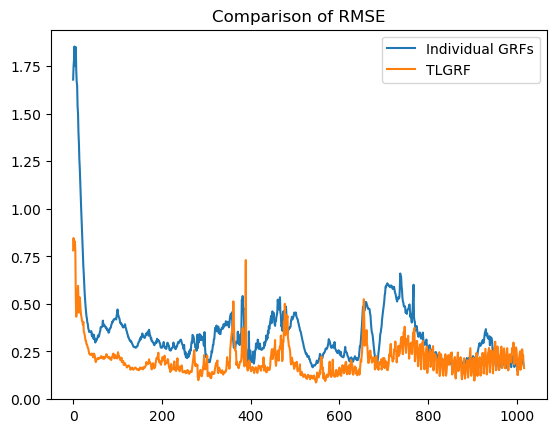

In [82]:
plt.plot(individual_grfs_performance['RMSE'], label='Individual GRFs')
plt.plot(TLGRF_performance['block.rmse.last'], label='TLGRF')

# Set plot title and legend
plt.title('Comparison of RMSE')
plt.legend()

# Show the plot
plt.show()

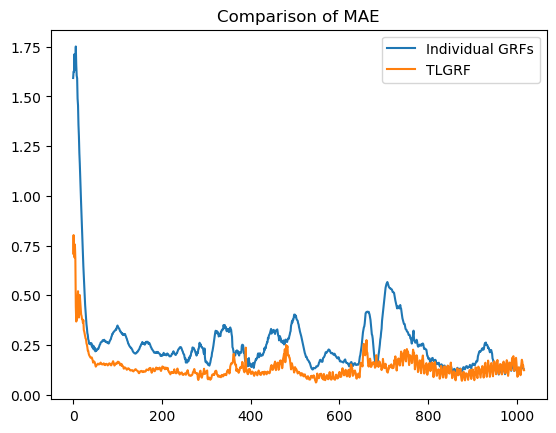

In [81]:
plt.plot(individual_grfs_performance['MAE'], label='Individual GRFs')
plt.plot(TLGRF_performance['block.mae.last'], label='TLGRF')

# Set plot title and legend
plt.title('Comparison of MAE')
plt.legend()

# Show the plot
plt.show()

In [84]:
tlgrf_median_rmse = TLGRF_performance['block.rmse.last'].median()
tlgrf_median_mae = TLGRF_performance['block.mae.last'].median()

# Calculate median RMSE and MAE for individual GRFs
ind_grfs_median_rmse = individual_grfs_performance['RMSE'].median()
ind_grfs_median_mae = individual_grfs_performance['MAE'].median()

# Create a summary statistics table
summary_table = pd.DataFrame({
    'Median RMSE': [ind_grfs_median_rmse, tlgrf_median_rmse],
    'Median MAE': [ind_grfs_median_mae, tlgrf_median_mae]
}, index=['Individual GRFs', 'TLGRF'])
summary_table

,Median RMSE,Median MAE
Individual GRFs,0.296518,0.21917
TLGRF,0.189374,0.12396


### Tabulate How Many Missing Results Per Day

In [85]:
n_fips = len(cases_df["fips"].unique())
n_fips

3143

In [101]:
TLGRF_results_path = "../data/output/merged_TLGRF_results.csv"
TLGRF_results_df = dd.read_csv(TLGRF_results_path, assume_missing=True).compute()
TLGRF_results_df.sort_values(["fips","days_from_start"])
TLGRF_results_df.head()

,fips,county,state,date.x,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,...,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x
0,1001.0,Autauga,Alabama,2022-04-30,65.0,830.0,4.721047,1017.214768,-0.024561,4.426311,...,-17.285714,0.055757,0.050457,0.479149,0.236129,0.224627,0.101492,0.050016,0.047580,NaN
1,1003.0,Baldwin,Alabama,2022-04-30,52.0,830.0,5.163969,1131.248123,-0.016862,4.961625,...,0.285714,0.023630,0.018729,0.245451,0.153721,0.136856,0.047531,0.029768,0.026502,NaN
2,1009.0,Blount,Alabama,2022-04-30,13.0,830.0,4.158883,962.427611,-0.030510,3.826826,...,-0.857143,0.008545,0.007805,0.058649,0.092437,0.088346,0.014102,0.022226,0.021243,NaN
3,1015.0,Calhoun,Alabama,2022-04-30,20.0,830.0,3.579543,773.583462,0.068170,4.323120,...,13.000000,0.109359,0.101036,0.248195,0.330694,0.317862,0.069337,0.092385,0.088800,NaN
4,1021.0,Chilton,Alabama,2022-04-30,13.0,830.0,4.143135,1077.201008,-0.016428,3.946000,...,1.142857,0.000173,0.000059,0.006739,0.013149,0.007710,0.001627,0.003174,0.001861,NaN


In [104]:
TLGRF_counts = TLGRF_results_df.groupby('days_from_start')["tau.hat"].count()
TLGRF_counts

days_from_start
51.0         5
52.0         6
53.0         8
54.0        10
55.0        14
          ... 
1071.0    2676
1072.0    2674
1073.0    2667
1074.0    2664
1075.0    2658
Name: tau.hat, Length: 1025, dtype: int64

In [90]:
individual_grfs_counts = merged_individual_grfs_df.groupby('days_from_start')["tau.hat"].count()
individual_grfs_counts

days_from_start
53         7
54         9
55        13
56        17
57        24
        ... 
1071    2672
1072    2670
1073    2663
1074    2661
1075    2655
Name: tau.hat, Length: 1023, dtype: int64

In [106]:
grf_counts = pd.DataFrame()
grf_counts["TLGRF_counts"] = TLGRF_counts
grf_counts["individual_grfs_counts"] = individual_grfs_counts
grf_counts["total"] = n_fips
grf_counts = grf_counts.reset_index()

grf_counts

,days_from_start,TLGRF_counts,individual_grfs_counts,total
0,51.0,5,NaN,3143
1,52.0,6,NaN,3143
2,53.0,8,7.0,3143
3,54.0,10,9.0,3143
4,55.0,14,13.0,3143
...,...,...,...,...
1020,1071.0,2676,2672.0,3143
1021,1072.0,2674,2670.0,3143
1022,1073.0,2667,2663.0,3143
1023,1074.0,2664,2661.0,3143


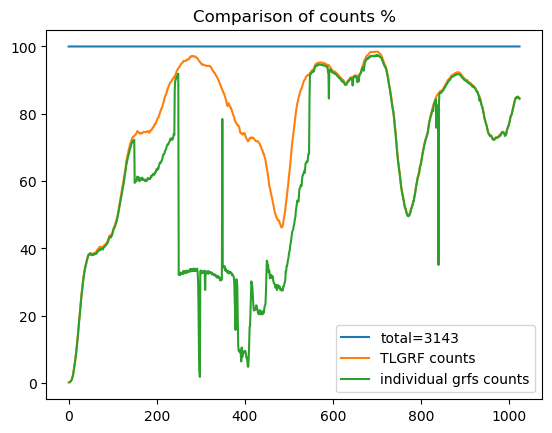

In [110]:
plt.plot(grf_counts['total']/n_fips * 100, label='total={}'.format(n_fips))
plt.plot(grf_counts['TLGRF_counts']/ n_fips * 100, label='TLGRF counts')
plt.plot(grf_counts['individual_grfs_counts']/ n_fips * 100, label='individual grfs counts')

# Set plot title and legend
plt.title('Comparison of counts %')
plt.legend()

# Show the plot
plt.show()

In [111]:
np.sum(grf_counts["individual_grfs_counts"])

1944282.0

In [112]:
n_fips * (1075-51)

3218432

In [113]:
np.sum(grf_counts["TLGRF_counts"])

2436813